In [ ]:
# --- plot_revision setup (auto-injected) ---
import sys
from pathlib import Path
# this notebook lives in plot_revision/scripts/, so plot_revision/ is its parent
_HERE = Path.cwd().resolve()
# tolerate cwd being either plot_revision/scripts or plot_revision or the repo root
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [18]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from importlib import reload
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.patches as patches

from plot_settings import *

from scipy.stats import gaussian_kde, spearmanr
import matplotlib.gridspec as gridspec

import matplotlib as mpl

plt.style.use('seaborn-v0_8-white')



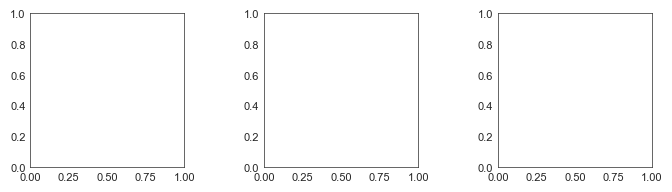

In [19]:
fig = plt.figure(figsize=(8.27, 3))

gs = gridspec.GridSpec(
    3, 3,  
    figure=fig,
    height_ratios=[0.5, 2, 0.5],
    hspace=0.0,
    wspace=0.35
)

axes = []
for i, row in enumerate([1]):
    row_axes = []
    for j in range(3):
        ax = fig.add_subplot(gs[row, j])
        row_axes.append(ax)
    axes.append(row_axes)

axes = np.array(axes)
for ax in axes.flatten():
    ax.set_aspect('equal')
    # ax.axis('off')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


In [20]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 1. results

In [21]:
all_results={
    'GM12878':{
        'Evo 2'   : [0.540135564803314, 0.35159966558201, 0.390445671882307, 0.564285248209467, 0.381692727714097],
        'HiC-only'    : [0.580339060048156, 0.423914818664619, 0.484999948615478, 0.564829449410029, 0.423593393424752],
        'Evo2HiC'     : [0.748282393261734, 0.552852844822536, 0.592083234225291, 0.766305867844135, 0.547865879055044],
    },
    'H1ESC':{
        'Evo 2'   : [0.682396098614877, 0.577837806260609, 0.604660268478918, 0.547157011822145, 0.441908014413656],
        'HiC-only'    : [0.70399517061336, 0.59435740533121, 0.616627974995683, 0.626398529935249, 0.518919842893362],
        'Evo2HiC'     : [0.822382629985575, 0.721047678616911, 0.740480452081525, 0.702524055466926, 0.624431925617015],
    },
    'K562':{
        'Evo 2'   : [0.524962810107566, 0.312086322556268, 0.443111628384052, 0.512365178418492, 0.261219917398181],
        'HiC-only'    : [0.677857305535807, 0.508132189227524, 0.553675060546619, 0.499904647316925, 0.47933507708421],
        'Evo2HiC'     : [0.744872434406798, 0.583033288643484, 0.566694456676332, 0.596802231226375, 0.523531252517244],
    },
}

In [22]:
statistic_tests = {
    'GM12878':[
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 )
    ],
    'H1ESC':[
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 )
    ],
    'K562':[
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'HiC-only',  1.7973863022972609e-155 ),
        ('Evo2HiC', 'HiC-only',  1.0 ),
        ('Evo2HiC', 'Evo 2',  0.0 ),
        ('Evo2HiC', 'HiC-only',  7.622773773146189e-28 )
    ]
}

# 2. radar plot (deprecated)

In [23]:
# # Data
# tracks = {
#     'DNase': 'DNase.bw', 
#     'CTCF': 'CTCF.bw', 
#     'H3K27ac': 'H3K27ac.bw',
#     'H3K27me3': 'H3K27me3.bw',
#     'H3K4me3': 'H3K4me3.bw'
# }

# labels = list(tracks.keys())

# # Prepare angle for each axis
# b = 0.1 * np.pi
# angles = np.linspace(b, b+2 * np.pi, len(labels), endpoint=False).tolist()
# angles += angles[:1]

# labels += [labels[0]]  # to close the loop

# # Plot
# fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw=dict(polar=True))

# for ax, (result_name, results) in zip(axs, all_results.items()):
#     for k,v in results.items():
#         result = results[k]+results[k][:1]
#         result = np.array(result)
#         ax.plot(angles, result, label=k, linewidth=2)
#         ax.fill(angles, result, alpha=0.1)

#     # Hide default tick labels
#     ax.set_xticks(angles[:-1])
#     ax.set_xticklabels([])

#     ax.set_yticklabels([])
#     top = 1.0
#     ax.set_ylim(bottom=0, top=top)
#     # Place custom radial tick labels *inside*
#     yticks = [0.2, 0.4, 0.6, 0.8, 1.0]
#     for y in yticks:
#         ax.text(np.radians(90), y-0.04,  # 90 degrees is top
#                 f"{y:.1f}",
#                 ha='center', va='center',
#                 fontsize=8, color='gray')
    
#     # Manually add rotated labels
#     for angle, label in zip(angles[:-1], labels[:-1]):
#         angle_deg = np.degrees(angle) + 90
#         radius = top + 0.05  # slightly beyond outer edge

#         alignment = 'center'
#         angle_deg += 180

#         ax.text(angle, radius, label,
#                 horizontalalignment=alignment,
#                 verticalalignment='center',
#                 rotation=angle_deg,
#                 rotation_mode='anchor',
#                 fontsize=10)

#     ax.set_title(result_name, pad=30)

# # Legend
# axs[-1].legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

# plt.tight_layout()
# plt.savefig(str(OUT_DIR / 'track_result_radar.pdf'))
# plt.show()

# 3. barplot

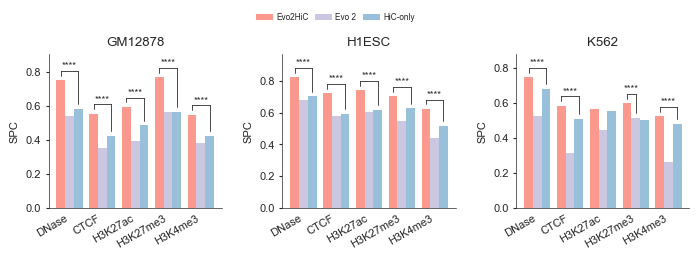

In [24]:
from plot_utils import _p_to_stars, _annotate_pair_asymmetric
# Data
tracks = {
    'DNase': 'DNase.bw', 
    'CTCF': 'CTCF.bw', 
    'H3K27ac': 'H3K27ac.bw',
    'H3K27me3': 'H3K27me3.bw',
    'H3K4me3': 'H3K4me3.bw'
}
labels = list(tracks.keys())

methods = ['Evo2HiC', 'Evo 2', 'HiC-only']

# 方法 -> 索引
meth2idx = {m:i for i, m in enumerate(methods)}

for ax, (result_name, results) in zip(axes.flatten(), all_results.items()):
    ax.clear()
    ax.set_aspect('auto')

    # --- 画柱子 ---
    n_m = len(methods)
    width = 0.8 / n_m
    x = np.arange(len(labels))

    for i, m in enumerate(methods):
        ax.bar(
            x + i*width, results[m],
            width=width,
            label=m,
            color=colors[i % len(colors)],
            alpha=0.8
        )

    ax.set_ylabel("SPC")
    ax.set_title(result_name)
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', length=2)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([])

    # --- 预留顶部空间，避免星号/支架被裁掉 ---
    max_val = np.nanmax([np.asarray(results[m]) for m in methods])
    ymin, ymax = 0.0, float(max_val * 1.18)  # 适当抬高 18%
    ax.set_ylim(ymin, ymax)

    # --- 根据 statistic_tests 画“非对称支架 + 星号” ---
    tests = statistic_tests.get(result_name, [])
    # 如果 tests 数量和 tracks 数量一致：逐 track 取一个；否则也能按 min 长度走
    for t_idx, tup in enumerate(tests[:len(labels)]):
        m1, m2, p = tup
        # 忽略 None 或非法方法名
        if (m1 not in meth2idx) or (m2 not in meth2idx):
            continue

        # 左右柱子的 x 位置
        x_left  = x[t_idx] + meth2idx[m1] * width
        x_right = x[t_idx] + meth2idx[m2] * width

        # 左右柱子的“cap”高度（就是柱顶）
        y_cap_left  = float(results[m1][t_idx])
        y_cap_right = float(results[m2][t_idx])

        # p -> 星号
        stars = _p_to_stars(p if p is not None else 1.0)

        if stars == 'n.s.': continue

        # 画支架（你提供的辅助函数，已支持非对称脚）
        _annotate_pair_asymmetric(
            ax,
            x_left=x_left, x_right=x_right,
            y_cap_left=y_cap_left, y_cap_right=y_cap_right,
            pad_frac=0.03,   # 比默认稍小，避免顶到上沿
            arm_frac=0.03,
            text=stars,
            lw=0.5, fontsize=7
        )

    ax.set_xticks(x + width*(len(methods)-1)/2)
    ax.set_xticklabels(labels, rotation=30, ha='right')


# Legend 维持你原来的做法
pos0, pos1 = axes[0][0].get_position(), axes[0][1].get_position()
x = (pos0.x0+pos1.x1)/2
y = pos0.y1+0.15
handles, leg_labels = axes[0][0].get_legend_handles_labels()
if hasattr(fig, "legend_") and fig.legend_ is not None:
    fig.legend_.remove()
fig.legend(
    handles, leg_labels,
    loc='upper left',
    bbox_to_anchor=(x, y),
    ncol=len(leg_labels),
    frameon=False,
    fontsize=6,
    handletextpad=0.4,
    columnspacing=0.8,
    borderaxespad=0.1
)
fig

In [25]:
labels = ['a', 'b', 'c']

for ax, label in zip(axes[0], labels):
    ax.text(
        -0.15, 1.15, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )


In [26]:
fig.savefig(str(OUT_DIR / 'supplementary_7.pdf'))